# Notebook 3 — Extended Intermediate Outlier Detection Methods

## Project Continuation

In the previous notebook, we completed the required Intermediate section:

- Isolation Forest
- Local Outlier Factor
- Jaccard coefficient
- PCA visualization

Now we continue with additional outlier detection methods from the uploaded theory/code material:

1. **ABOD — Angle-Based Outlier Detection**
2. **CBLOF — Cluster-Based Local Outlier Factor**
3. **LoOP — Local Outlier Probability**

These methods help us understand different ways of detecting unusual rows.

We will again use the Industrial Equipment Monitoring dataset and the same four sensor columns:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

Each row is one machine observation, also called one data point.

In [30]:
# ============================================================
# Notebook 3: Extended Intermediate Outlier Detection
# Cell 1A: Imports, settings, and dataset loading
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Project settings
# ------------------------------------------------------------

RANDOM_STATE = 42
CONTAMINATION = 0.05

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

# The CSV file should be in the same folder as this notebook.
DATA_PATH = Path.cwd() / "equipment_anomaly_data.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV file not found: {DATA_PATH}\n"
        "Please place equipment_anomaly_data.csv in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

display(df.head())

Dataset loaded successfully.
Dataset shape: 7672 rows and 7 columns


,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


In [31]:
# ============================================================
# Cell 1B: Select and scale sensor features
# ============================================================

from sklearn.preprocessing import StandardScaler

# Select sensor columns only
sensor_columns = ["temperature", "pressure", "vibration", "humidity"]

X = df[sensor_columns].copy()

# Scale features so all sensors are comparable
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=sensor_columns,
    index=df.index
)

print("Feature scaling completed.")
print(f"Sensor columns: {sensor_columns}")
print(f"Scaled feature shape: {X_scaled.shape}")

display(X_scaled.head())

Feature scaling completed.
Sensor columns: ['temperature', 'pressure', 'vibration', 'humidity']
Scaled feature shape: (7672, 4)


,temperature,pressure,vibration,humidity
0,-0.786610,-1.031582,-1.379925,-0.364984
1,0.297440,-1.231493,0.996943,-0.688233
2,0.026922,-0.815074,-0.305569,0.754840
3,0.042873,-0.336688,0.218089,-0.798215
4,-0.272588,0.911232,-1.738352,-0.571147


### Conclusion — Features Scaled

The four sensor columns were selected and scaled successfully:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

The scaled feature matrix has **7,672 rows and 4 columns**.

These scaled features are now ready for the extended outlier detection methods:

- ABOD
- CBLOF
- LoOP

In [32]:
# ============================================================
# Cell 2: Check required packages for extended methods
# ============================================================

packages_to_check = {
    "pyod": "ABOD and CBLOF",
    "PyNomaly": "LoOP"
}

for package_name, purpose in packages_to_check.items():
    try:
        __import__(package_name)
        print(f"{package_name} is installed. Used for: {purpose}")
    except ImportError:
        print(f"{package_name} is NOT installed. Used for: {purpose}")

pyod is installed. Used for: ABOD and CBLOF
PyNomaly is installed. Used for: LoOP


In [33]:
# ============================================================
# Cell 3: Install required packages for extended outlier methods
# ============================================================

%pip install pyod PyNomaly

Note: you may need to restart the kernel to use updated packages.


In [34]:
# ============================================================
# Fix package installation using conda-forge
# ============================================================

%conda install -c conda-forge pyod pynomaly -y

Channels:
 - conda-forge
 - defaults
Platform: osx-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.1.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [35]:
# ============================================================
# Cell 4: Verify ABOD, CBLOF, and LoOP imports
# ============================================================

from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from PyNomaly import loop

print("ABOD ready")
print("CBLOF ready")
print("LoOP ready")

ABOD ready
CBLOF ready
LoOP ready


## Step 5 — ABOD: Angle-Based Outlier Detection

ABOD stands for **Angle-Based Outlier Detection**.

The simple idea is:

**ABOD checks whether a row is surrounded by other rows from many directions.**

If a row is inside a normal data cloud, other rows are around it from many angles.

If a row is outside the normal data cloud, most other rows are usually in one general direction.

So:

- many different angles = likely normal
- fewer angle variations = possible outlier

ABOD is useful because it does not rely only on distance.  
This can help in higher-dimensional data where distance-based methods can become weaker.

In [36]:
# ============================================================
# Cell 5: Train ABOD model
# ============================================================

from pyod.models.abod import ABOD

# Create ABOD model
# contamination=0.05 means approximately 5% of rows will be flagged as outliers.
abod_model = ABOD(
    contamination=CONTAMINATION
)

# Train ABOD on scaled sensor features
abod_model.fit(X_scaled)

# ABOD labels:
# 0 = normal
# 1 = outlier
abod_labels = abod_model.labels_

# Add ABOD results to dataframe
df_extended = df.copy()
df_extended["abod_label"] = abod_labels
df_extended["abod_outlier"] = df_extended["abod_label"] == 1

# Count ABOD outliers
abod_outlier_count = df_extended["abod_outlier"].sum()
abod_outlier_percentage = abod_outlier_count / len(df_extended) * 100

print("ABOD training completed.")
print(f"Contamination setting: {CONTAMINATION}")
print(f"ABOD outliers detected: {abod_outlier_count}")
print(f"Outlier percentage: {abod_outlier_percentage:.2f}%")

display(
    df_extended[
        sensor_columns + ["equipment", "location", "faulty", "abod_outlier"]
    ].head()
)

ABOD training completed.
Contamination setting: 0.05
ABOD outliers detected: 384
Outlier percentage: 5.01%


,temperature,pressure,vibration,humidity,equipment,location,faulty,abod_outlier
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0,False
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0,False
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0,False
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0,False
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0,False


### Conclusion — ABOD Outliers Detected

The ABOD model was trained successfully on the scaled sensor features.

We used:

`contamination = 0.05`

The model detected:

- **384 ABOD outlier rows**
- **5.01%** of the dataset

This matches the expected contamination level.

ABOD uses a different logic from Isolation Forest and LOF.

Instead of focusing mainly on random isolation or local density, ABOD uses angle-based relationships between rows.

In simple terms:

- a normal row is usually surrounded by other rows from many directions
- an outlier row may sit outside the main data cloud, so most other rows appear in one general direction

This means ABOD may detect a different type of unusual sensor pattern.

In the next step, we will train CBLOF, which uses cluster-based outlier logic.

## Step 5C — ABOD Outliers in PCA Space

Now we visualize the ABOD results using a PCA scatter plot.

ABOD is angle-based, so the PCA view helps us see where ABOD outliers appear in the compressed sensor space.

In this chart:

- grey points represent normal rows
- red points represent ABOD outlier rows
- each point is one machine observation
- PC1 and PC2 summarize the four original sensor columns

Normal rows: 7,288
ABOD outlier rows: 384
PC1 explained variance: 28.20%
PC2 explained variance: 25.22%
Total explained variance: 53.41%


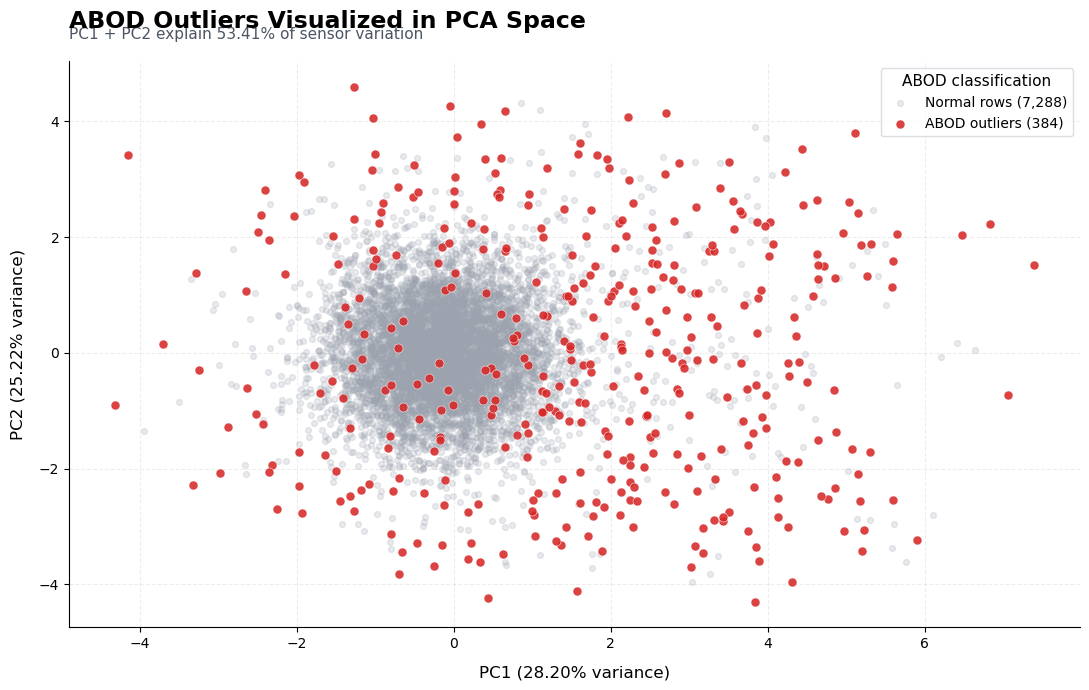

In [37]:
# ============================================================
# Cell 5C: Professional PCA scatter plot - ABOD outliers
# ============================================================

from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Create PCA components if they do not already exist
# ------------------------------------------------------------

if "PC1" not in df_extended.columns or "PC2" not in df_extended.columns:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_components = pca.fit_transform(X_scaled)

    df_extended["PC1"] = pca_components[:, 0]
    df_extended["PC2"] = pca_components[:, 1]

    explained_variance = pca.explained_variance_ratio_
    total_explained_variance = explained_variance.sum()
else:
    # Recreate PCA object only to get explained variance values consistently
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca.fit(X_scaled)
    explained_variance = pca.explained_variance_ratio_
    total_explained_variance = explained_variance.sum()

# ------------------------------------------------------------
# 2. Split normal and ABOD outlier rows
# ------------------------------------------------------------

abod_normal_rows = df_extended[~df_extended["abod_outlier"]]
abod_outlier_rows = df_extended[df_extended["abod_outlier"]]

print(f"Normal rows: {len(abod_normal_rows):,}")
print(f"ABOD outlier rows: {len(abod_outlier_rows):,}")
print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {total_explained_variance:.2%}")

# ------------------------------------------------------------
# 3. Create professional scatter plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Normal rows
ax.scatter(
    abod_normal_rows["PC1"],
    abod_normal_rows["PC2"],
    s=18,
    alpha=0.22,
    color="#9CA3AF",
    label=f"Normal rows ({len(abod_normal_rows):,})"
)

# ABOD outlier rows
ax.scatter(
    abod_outlier_rows["PC1"],
    abod_outlier_rows["PC2"],
    s=42,
    alpha=0.88,
    color="#D62828",
    edgecolor="white",
    linewidth=0.4,
    label=f"ABOD outliers ({len(abod_outlier_rows):,})"
)

# Title
ax.set_title(
    "ABOD Outliers Visualized in PCA Space",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

# Subtitle
ax.text(
    0,
    1.04,
    f"PC1 + PC2 explain {total_explained_variance:.2%} of sensor variation",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel(
    f"PC1 ({explained_variance[0]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    f"PC2 ({explained_variance[1]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="both", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)

# Legend
ax.legend(
    title="ABOD classification",
    frameon=True,
    facecolor="white",
    edgecolor="#D1D5DB",
    fontsize=10,
    title_fontsize=11,
    loc="best"
)

plt.tight_layout()
plt.show()

### Cell 5C Conclusion — ABOD Outliers in PCA Space

The PCA scatter plot shows where the ABOD outliers appear in the compressed two-dimensional sensor space.

ABOD detected:

- **384 outlier rows**
- **5.01%** of the dataset

The PCA plot uses two components:

- `PC1`
- `PC2`

Together, these components explain approximately **53.41%** of the sensor variation.

In the chart:

- grey points represent normal rows
- red points represent ABOD outlier rows

The ABOD outliers appear around the outer regions of the PCA space, which suggests that ABOD is identifying rows with unusual geometric relationships compared to the main data cloud.

This matches the logic of ABOD:

- normal rows are usually surrounded by other rows from many directions
- outlier rows tend to sit outside the main data cloud, where surrounding points appear from fewer directions

From a machine monitoring perspective, ABOD outliers may represent sensor patterns that are unusual in terms of overall geometric position, not only because one sensor value is extremely high or low.

## CBLOF: Cluster-Based Local Outlier Factor

CBLOF stands for **Cluster-Based Local Outlier Factor**.

The simple idea is:

**CBLOF detects outliers using cluster behavior.**

It first groups similar rows into clusters.

Then it checks whether a row is suspicious because:

- it belongs to a small unusual cluster
- or it is far away from the center of a larger normal cluster

In simple words:

**CBLOF asks whether a row belongs to a strange small group or sits far from its cluster center.**

In [38]:
# ============================================================
# Cell 6: Train CBLOF model
# ============================================================

from pyod.models.cblof import CBLOF

# Create CBLOF model
# contamination=0.05 means approximately 5% of rows will be flagged as outliers.
cblof_model = CBLOF(
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE
)

# Train CBLOF on scaled sensor features
cblof_model.fit(X_scaled)

# CBLOF labels:
# 0 = normal
# 1 = outlier
cblof_labels = cblof_model.labels_

# Add CBLOF results to dataframe
df_extended["cblof_label"] = cblof_labels
df_extended["cblof_outlier"] = df_extended["cblof_label"] == 1

# Count CBLOF outliers
cblof_outlier_count = df_extended["cblof_outlier"].sum()
cblof_outlier_percentage = cblof_outlier_count / len(df_extended) * 100

print("CBLOF training completed.")
print(f"Contamination setting: {CONTAMINATION}")
print(f"CBLOF outliers detected: {cblof_outlier_count}")
print(f"Outlier percentage: {cblof_outlier_percentage:.2f}%")

display(
    df_extended[
        sensor_columns + ["equipment", "location", "faulty", "cblof_outlier"]
    ].head()
)

CBLOF training completed.
Contamination setting: 0.05
CBLOF outliers detected: 384
Outlier percentage: 5.01%


,temperature,pressure,vibration,humidity,equipment,location,faulty,cblof_outlier
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0,False
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0,False
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0,False
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0,False
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0,False


### Conclusion — CBLOF Outliers Detected

The CBLOF model was trained successfully on the scaled sensor features.

We used:

`contamination = 0.05`

The model detected:

- **384 CBLOF outlier rows**
- **5.01%** of the dataset

This matches the expected contamination level.

CBLOF uses cluster-based logic.

In simple terms:

- it groups similar rows into clusters
- rows in small unusual clusters can be suspicious
- rows far from a cluster center can also be suspicious

This means CBLOF may detect outliers that are unusual because of their cluster position, not only because of extreme individual sensor values.

In the next step, we will create a CBLOF detection summary chart.

## Step 6B — CBLOF Outliers in PCA Space

Now we visualize the CBLOF results using a PCA scatter plot.

CBLOF is cluster-based, so a 2D PCA view helps us see whether the detected outliers appear near the edges of the sensor space or away from the main data cloud.

In this chart:

- grey points represent normal rows
- red points represent CBLOF outlier rows
- each point is one machine observation
- PC1 and PC2 are compressed versions of the original sensor columns

Normal rows: 7,288
CBLOF outlier rows: 384
PC1 explained variance: 28.20%
PC2 explained variance: 25.22%
Total explained variance: 53.41%


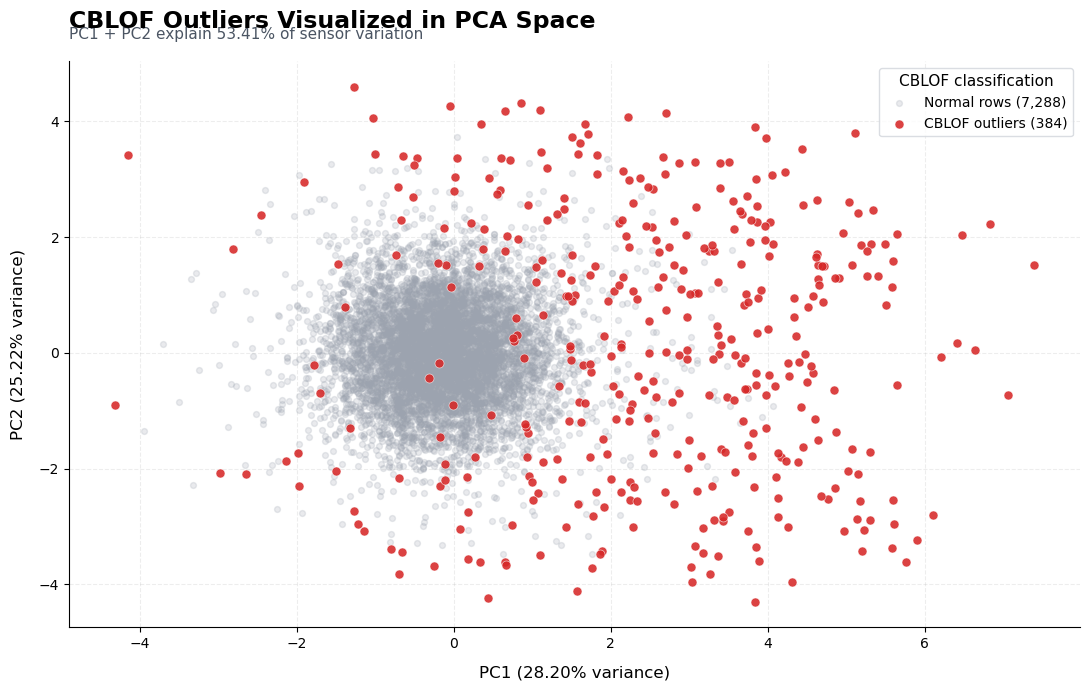

In [39]:
# ============================================================
# Cell 6B: Professional PCA scatter plot - CBLOF outliers
# ============================================================

from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Create PCA components for 2D visualization
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=RANDOM_STATE)

pca_components = pca.fit_transform(X_scaled)

df_extended["PC1"] = pca_components[:, 0]
df_extended["PC2"] = pca_components[:, 1]

explained_variance = pca.explained_variance_ratio_
total_explained_variance = explained_variance.sum()

# ------------------------------------------------------------
# 2. Split normal and CBLOF outlier rows
# ------------------------------------------------------------

cblof_normal_rows = df_extended[~df_extended["cblof_outlier"]]
cblof_outlier_rows = df_extended[df_extended["cblof_outlier"]]

print(f"Normal rows: {len(cblof_normal_rows):,}")
print(f"CBLOF outlier rows: {len(cblof_outlier_rows):,}")
print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {total_explained_variance:.2%}")

# ------------------------------------------------------------
# 3. Create professional scatter plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Normal rows
ax.scatter(
    cblof_normal_rows["PC1"],
    cblof_normal_rows["PC2"],
    s=18,
    alpha=0.22,
    color="#9CA3AF",
    label=f"Normal rows ({len(cblof_normal_rows):,})"
)

# CBLOF outlier rows
ax.scatter(
    cblof_outlier_rows["PC1"],
    cblof_outlier_rows["PC2"],
    s=42,
    alpha=0.88,
    color="#D62828",
    edgecolor="white",
    linewidth=0.4,
    label=f"CBLOF outliers ({len(cblof_outlier_rows):,})"
)

# Title
ax.set_title(
    "CBLOF Outliers Visualized in PCA Space",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

# Subtitle
ax.text(
    0,
    1.04,
    f"PC1 + PC2 explain {total_explained_variance:.2%} of sensor variation",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel(
    f"PC1 ({explained_variance[0]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    f"PC2 ({explained_variance[1]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="both", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)

# Legend
ax.legend(
    title="CBLOF classification",
    frameon=True,
    facecolor="white",
    edgecolor="#D1D5DB",
    fontsize=10,
    title_fontsize=11,
    loc="best"
)

plt.tight_layout()
plt.show()

### Cell 6B Conclusion — CBLOF Outliers in PCA Space

The PCA scatter plot shows where the CBLOF outliers appear in the compressed two-dimensional sensor space.

CBLOF detected:

- **384 outlier rows**
- **5.01%** of the dataset

The PCA plot uses:

- `PC1`
- `PC2`

Together, these components explain approximately **53.41%** of the sensor variation.

In the chart:

- grey points represent normal rows
- red points represent CBLOF outlier rows

The CBLOF outliers appear mostly around the outer parts of the PCA space and away from the dense central region.

This fits the logic of CBLOF:

- it first groups rows into clusters
- rows in small unusual clusters can be suspicious
- rows far from a cluster center can also be suspicious

From a machine monitoring perspective, CBLOF outliers may represent unusual operating groups or sensor readings that do not fit well into the main equipment behavior clusters.

## Step 7 — LoOP: Local Outlier Probability

LoOP stands for **Local Outlier Probability**.

LoOP is similar in spirit to LOF because it looks at local neighborhoods.

The simple idea is:

**LoOP checks how likely a row is to be locally unusual.**

Instead of only giving an outlier label, LoOP gives a probability-style score.

Interpretation:

- score close to `0` = likely normal
- score close to `1` = likely outlier

For comparison with the other methods, we will mark the top **5% highest LoOP scores** as outliers.

In [40]:
# ============================================================
# Cell 7: Train LoOP and create outlier flag
# ============================================================

from PyNomaly import loop

# ------------------------------------------------------------
# 1. Train LoOP model
# ------------------------------------------------------------

# LoOP uses local neighborhood distance logic.
# n_neighbors controls how many nearby rows are used for comparison.
loop_model = loop.LocalOutlierProbability(
    X_scaled.values,
    n_neighbors=20,
    extent=3
)

loop_model.fit()

# Extract LoOP probability scores.
# Higher score means more likely to be an outlier.
loop_scores = np.array(loop_model.local_outlier_probabilities)

# ------------------------------------------------------------
# 2. Add LoOP scores to dataframe
# ------------------------------------------------------------

df_extended["loop_score"] = loop_scores

# ------------------------------------------------------------
# 3. Mark top 5% highest LoOP scores as outliers
# ------------------------------------------------------------

loop_threshold = np.quantile(
    df_extended["loop_score"],
    1 - CONTAMINATION
)

df_extended["loop_outlier"] = (
    df_extended["loop_score"] >= loop_threshold
)

# Count LoOP outliers
loop_outlier_count = df_extended["loop_outlier"].sum()
loop_outlier_percentage = loop_outlier_count / len(df_extended) * 100

print("LoOP scoring completed.")
print(f"LoOP threshold used: {loop_threshold:.4f}")
print(f"LoOP outliers detected: {loop_outlier_count}")
print(f"Outlier percentage: {loop_outlier_percentage:.2f}%")

display(
    df_extended[
        sensor_columns + ["equipment", "location", "faulty", "loop_score", "loop_outlier"]
    ]
    .sort_values("loop_score", ascending=False)
    .head(10)
)

LoOP scoring completed.
LoOP threshold used: 0.5408
LoOP outliers detected: 384
Outlier percentage: 5.01%


,temperature,pressure,vibration,humidity,equipment,location,faulty,loop_score,loop_outlier
4405,46.421400,46.809892,2.959962,45.657875,Pump,New York,1.0,0.988125,True
3725,61.925562,16.510793,0.133936,74.636657,Compressor,Houston,1.0,0.985856,True
1133,14.612445,12.437942,0.192578,87.919799,Turbine,Atlanta,1.0,0.975829,True
568,66.921915,3.620798,1.338323,70.551927,Compressor,Houston,0.0,0.9755,True
5266,99.821267,11.563752,0.496328,37.450667,Pump,Chicago,1.0,0.97144,True
53,66.417556,37.866673,2.583442,81.589418,Turbine,Chicago,0.0,0.970664,True
3096,56.643161,63.631646,2.345458,63.226452,Pump,Chicago,1.0,0.962731,True
4254,64.213735,57.162722,2.215312,13.888359,Compressor,Houston,1.0,0.958612,True
1419,101.515289,35.484639,2.521078,89.883652,Pump,New York,1.0,0.953854,True
4773,62.740696,12.846157,2.235957,11.370926,Turbine,New York,1.0,0.9464,True


### Cell 7 Conclusion — LoOP Outliers Detected

The LoOP method was applied successfully to the scaled sensor features.

LoOP produced a probability-style outlier score for each row.

The threshold used was:

`0.5408`

Rows with a LoOP score greater than or equal to this threshold were marked as outliers.

The result was:

- **384 LoOP outlier rows**
- **5.01%** of the dataset

This matches the top 5% selection rule used for comparison with the other extended methods.

LoOP is similar to LOF because it uses local neighborhood behavior.

However, instead of only giving an outlier label, LoOP gives a probability-style score.

In simple terms:

- low LoOP score = likely normal
- high LoOP score = likely locally unusual

In the next step, we will create a professional LoOP score distribution chart to understand how the scores are spread across the dataset.

## Step 7B — LoOP Score Distribution

Now we visualize the LoOP score distribution.

LoOP gives each row a probability-style outlier score.

This chart helps answer:

**How are LoOP anomaly scores distributed across the dataset?**

In this chart:

- most normal rows should have lower LoOP scores
- rows near the right side are more suspicious
- the red dashed line shows the threshold used to mark the top 5% as outliers

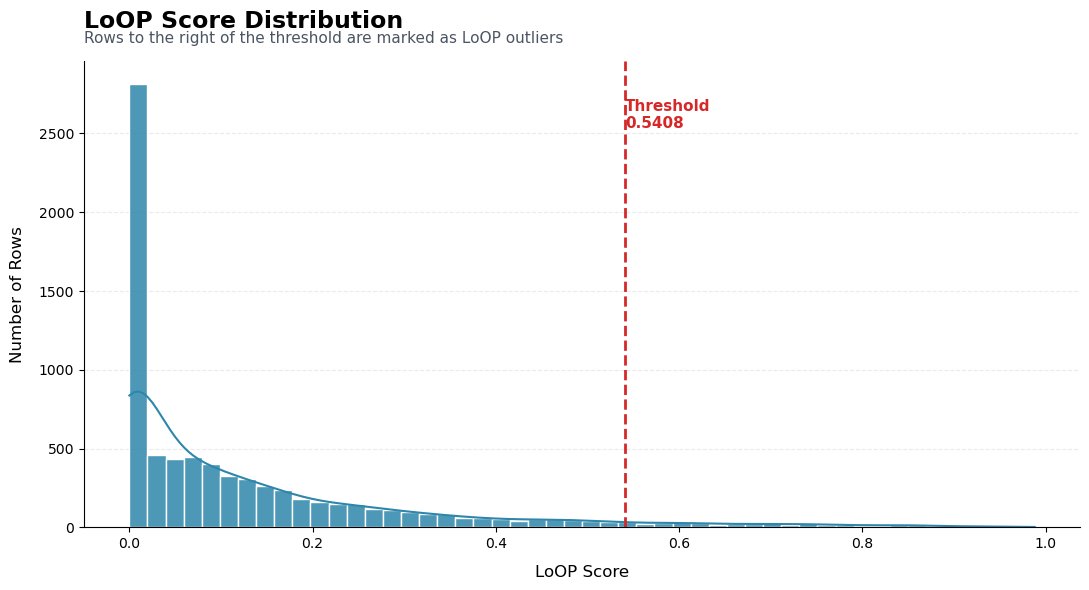

,loop_score_summary
count,7672.0
unique,5325.0
top,0.0
freq,2348.0


In [41]:
# ============================================================
# Cell 7B: Professional chart - LoOP score distribution
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

# Plot LoOP score distribution
sns.histplot(
    data=df_extended,
    x="loop_score",
    bins=50,
    kde=True,
    color="#2E86AB",
    edgecolor="white",
    alpha=0.85,
    ax=ax
)

# Add threshold line
ax.axvline(
    loop_threshold,
    color="#D62828",
    linestyle="--",
    linewidth=2
)

# Add threshold label
ax.text(
    loop_threshold,
    ax.get_ylim()[1] * 0.92,
    f"Threshold\n{loop_threshold:.4f}",
    ha="left",
    va="top",
    fontsize=11,
    color="#D62828",
    fontweight="bold"
)

# Title and subtitle
ax.set_title(
    "LoOP Score Distribution",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.04,
    "Rows to the right of the threshold are marked as LoOP outliers",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel("LoOP Score", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Rows", fontsize=12, labelpad=10)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Display score summary
display(
    df_extended["loop_score"]
    .describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])
    .to_frame("loop_score_summary")
)

### Cell 7B Conclusion — LoOP Score Distribution

The LoOP score distribution shows that most rows have very low anomaly scores.

This means most machine observations are considered locally normal by the LoOP method.

The distribution is strongly right-skewed:

- many rows have scores close to `0`
- fewer rows have medium scores
- only a small number of rows have high LoOP scores

The threshold used to mark outliers was:

`0.5408`

Rows with LoOP scores greater than or equal to this threshold were marked as outliers.

This selected the top **5%** highest LoOP scores, resulting in:

- **384 LoOP outlier rows**
- **5.01%** of the dataset

The chart is useful because it shows that LoOP does not treat all rows equally.  
Instead, it assigns a gradual probability-style score, where higher scores indicate stronger local abnormality.

From a machine monitoring perspective, rows on the far-right side of the distribution should be inspected first because they are the most locally unusual according to LoOP.

## Step 7C — LoOP Outliers in PCA Space

Now we visualize the LoOP outliers using a PCA scatter plot.

LoOP detects locally unusual rows using probability-style anomaly scores.

The PCA view helps us see where LoOP outliers appear in the compressed sensor space.

In this chart:

- grey points represent normal rows
- red points represent LoOP outlier rows
- each point is one machine observation
- PC1 and PC2 summarize the four original sensor columns

Normal rows: 7,288
LoOP outlier rows: 384
PC1 explained variance: 28.20%
PC2 explained variance: 25.22%
Total explained variance: 53.41%


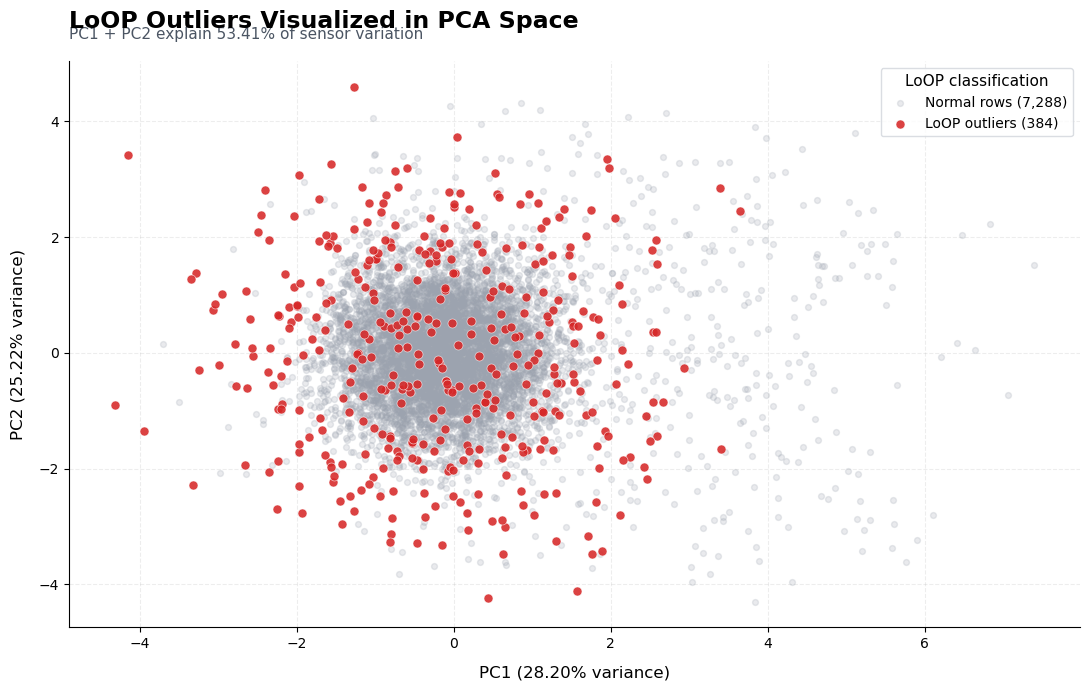

In [42]:
# ============================================================
# Cell 7C: Professional PCA scatter plot - LoOP outliers
# ============================================================

from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Create PCA components if they do not already exist
# ------------------------------------------------------------

if "PC1" not in df_extended.columns or "PC2" not in df_extended.columns:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_components = pca.fit_transform(X_scaled)

    df_extended["PC1"] = pca_components[:, 0]
    df_extended["PC2"] = pca_components[:, 1]

    explained_variance = pca.explained_variance_ratio_
    total_explained_variance = explained_variance.sum()
else:
    # Refit PCA only to get the explained variance values for labels
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca.fit(X_scaled)

    explained_variance = pca.explained_variance_ratio_
    total_explained_variance = explained_variance.sum()

# ------------------------------------------------------------
# 2. Split normal and LoOP outlier rows
# ------------------------------------------------------------

loop_normal_rows = df_extended[~df_extended["loop_outlier"]]
loop_outlier_rows = df_extended[df_extended["loop_outlier"]]

print(f"Normal rows: {len(loop_normal_rows):,}")
print(f"LoOP outlier rows: {len(loop_outlier_rows):,}")
print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {total_explained_variance:.2%}")

# ------------------------------------------------------------
# 3. Create professional scatter plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Normal rows
ax.scatter(
    loop_normal_rows["PC1"],
    loop_normal_rows["PC2"],
    s=18,
    alpha=0.22,
    color="#9CA3AF",
    label=f"Normal rows ({len(loop_normal_rows):,})"
)

# LoOP outlier rows
ax.scatter(
    loop_outlier_rows["PC1"],
    loop_outlier_rows["PC2"],
    s=42,
    alpha=0.88,
    color="#D62828",
    edgecolor="white",
    linewidth=0.4,
    label=f"LoOP outliers ({len(loop_outlier_rows):,})"
)

# Title
ax.set_title(
    "LoOP Outliers Visualized in PCA Space",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

# Subtitle
ax.text(
    0,
    1.04,
    f"PC1 + PC2 explain {total_explained_variance:.2%} of sensor variation",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel(
    f"PC1 ({explained_variance[0]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    f"PC2 ({explained_variance[1]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="both", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)

# Legend
ax.legend(
    title="LoOP classification",
    frameon=True,
    facecolor="white",
    edgecolor="#D1D5DB",
    fontsize=10,
    title_fontsize=11,
    loc="best"
)

plt.tight_layout()
plt.show()

### Cell 7C Conclusion — LoOP Outliers in PCA Space

The PCA scatter plot shows where the LoOP outliers appear in the compressed two-dimensional sensor space.

LoOP detected:

- **384 outlier rows**
- **5.01%** of the dataset

The PCA plot uses:

- `PC1`
- `PC2`

Together, these two components explain approximately **53.41%** of the sensor variation.

In the chart:

- grey points represent normal rows
- red points represent LoOP outlier rows

Unlike CBLOF, the LoOP outliers are not only concentrated far away from the main data cloud.  
Many LoOP outliers appear inside or near the dense central region.

This makes sense because LoOP is a local-neighborhood method.

LoOP does not only ask:

“Is this row far away from the whole dataset?”

Instead, it asks:

“Is this row unusual compared to its nearby rows?”

Therefore, a row can be marked as a LoOP outlier even if it is not visually far away in the PCA plot.

This explains why LoOP had low agreement with CBLOF in the pairwise Jaccard heatmap.

From a machine monitoring perspective, LoOP may detect subtle local abnormalities that cluster-based methods may miss.

## Step 8 — Pairwise Agreement Between ABOD, CBLOF, and LoOP

The previous count comparison is not very useful because all three methods were configured to flag approximately 5% of rows as outliers.

So each method detected the same number of outliers:

- ABOD: 384
- CBLOF: 384
- LoOP: 384

The more important question is:

**Are they detecting the same rows?**

To answer this, we calculate pairwise Jaccard agreement between the methods.

Jaccard compares the overlap between two outlier sets:

`Jaccard = shared outliers / total unique outliers`

Interpretation:

- `1.0` = perfect agreement
- `0.0` = no agreement
- lower values mean the methods detect different types of outliers

Pairwise Jaccard agreement:


,ABOD,CBLOF,LoOP
ABOD,1.0000,0.4463,0.1725
CBLOF,0.4463,1.0000,0.0254
LoOP,0.1725,0.0254,1.0000


Shared outlier counts:


,ABOD,CBLOF,LoOP
ABOD,384.0,237.0,113.0
CBLOF,237.0,384.0,19.0
LoOP,113.0,19.0,384.0


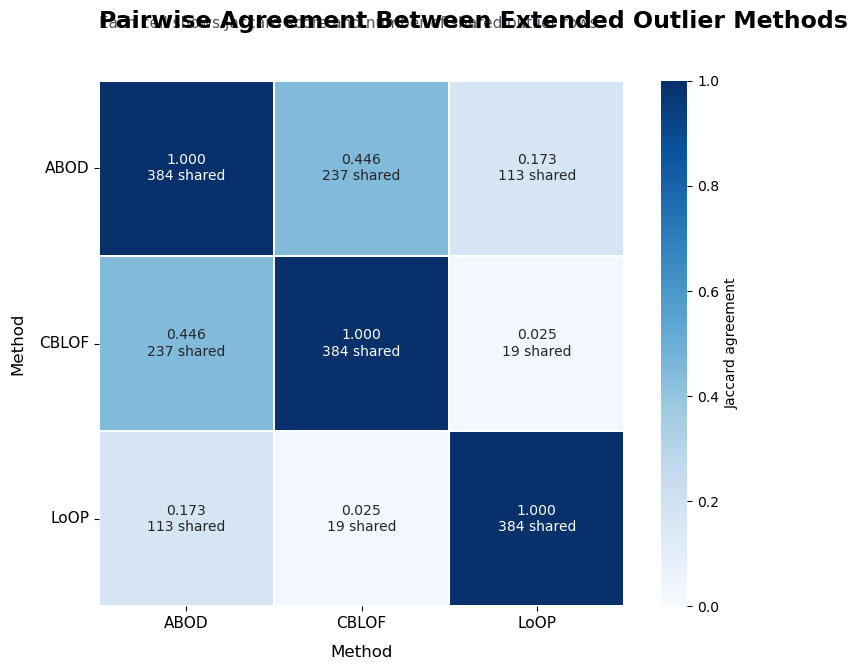

In [43]:
# ============================================================
# Cell 8: Pairwise agreement heatmap - ABOD, CBLOF, LoOP
# ============================================================

# Define extended method outlier columns
extended_methods = {
    "ABOD": "abod_outlier",
    "CBLOF": "cblof_outlier",
    "LoOP": "loop_outlier"
}

# Create outlier index sets for each method
outlier_sets = {
    method: set(df_extended.index[df_extended[column]])
    for method, column in extended_methods.items()
}

# Method names
method_names = list(extended_methods.keys())

# Create empty matrices
jaccard_matrix = pd.DataFrame(
    index=method_names,
    columns=method_names,
    dtype=float
)

shared_count_matrix = pd.DataFrame(
    index=method_names,
    columns=method_names,
    dtype=int
)

# Calculate pairwise Jaccard scores and shared outlier counts
for method_a in method_names:
    for method_b in method_names:
        set_a = outlier_sets[method_a]
        set_b = outlier_sets[method_b]
        
        shared_outliers = set_a.intersection(set_b)
        unique_outliers = set_a.union(set_b)
        
        jaccard_score = len(shared_outliers) / len(unique_outliers)
        
        jaccard_matrix.loc[method_a, method_b] = jaccard_score
        shared_count_matrix.loc[method_a, method_b] = len(shared_outliers)

# Create annotation labels for heatmap
annotation_labels = jaccard_matrix.copy().astype(str)

for method_a in method_names:
    for method_b in method_names:
        annotation_labels.loc[method_a, method_b] = (
            f"{jaccard_matrix.loc[method_a, method_b]:.3f}\n"
            f"{int(shared_count_matrix.loc[method_a, method_b]):,} shared"
        )

print("Pairwise Jaccard agreement:")
display(jaccard_matrix.round(4))

print("Shared outlier counts:")
display(shared_count_matrix)

# ------------------------------------------------------------
# Professional heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 6.8))

sns.heatmap(
    jaccard_matrix,
    annot=annotation_labels,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=1.2,
    linecolor="white",
    cbar_kws={"label": "Jaccard agreement"},
    square=True,
    ax=ax
)

# Main title
ax.set_title(
    "Pairwise Agreement Between Extended Outlier Methods",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=38
)

# Subtitle
ax.text(
    0,
    1.10,
    "Each cell shows Jaccard score and number of shared outlier rows",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel("Method", fontsize=12, labelpad=10)
ax.set_ylabel("Method", fontsize=12, labelpad=10)

# Tick styling
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

### Conclusion — Pairwise Agreement Between ABOD, CBLOF, and LoOP

The pairwise agreement analysis compares how much the extended outlier detection methods agree with each other.

Each method detected **384 outlier rows**, but the agreement table shows that they did not detect the same rows.

The pairwise Jaccard results were:

| Method Pair | Shared Outliers | Jaccard Agreement |
|---|---:|---:|
| ABOD vs CBLOF | 237 | 0.4463 |
| ABOD vs LoOP | 113 | 0.1725 |
| CBLOF vs LoOP | 19 | 0.0254 |

The strongest agreement is between **ABOD and CBLOF**.

This means ABOD and CBLOF detected more similar outlier rows compared with LoOP.

The weakest agreement is between **CBLOF and LoOP**.

Only **19 rows** were shared between CBLOF and LoOP, giving a very low Jaccard score of **0.0254**.

This means LoOP is detecting a very different type of anomaly compared with CBLOF.

Main interpretation:

- **ABOD** detects unusual angle-based patterns.
- **CBLOF** detects unusual cluster-based patterns.
- **LoOP** detects locally unusual rows using probability-style scores.

From a machine monitoring perspective, rows detected by multiple methods may deserve higher inspection priority.

However, rows detected by only one method should not be ignored, because each algorithm defines “unusual” differently.

## Step 9 — Combined Agreement Across ABOD, CBLOF, and LoOP

Now we combine the results from three outlier detection algorithms:

1. **ABOD — Angle-Based Outlier Detection**
   - Finds rows that look unusual based on angles and geometric position.

2. **CBLOF — Cluster-Based Local Outlier Factor**
   - Finds rows that belong to strange clusters or sit far away from cluster centers.

3. **LoOP — Local Outlier Probability**
   - Finds rows that are unusual compared to nearby rows.

Each algorithm looked at the same four sensor columns:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

For every row, we checked whether it was flagged by:

- ABOD
- CBLOF
- LoOP

Then we counted how many of these three algorithms flagged each row as an outlier.

The count means:

| Count | Meaning |
|---:|---|
| 0 | ABOD, CBLOF, and LoOP all considered the row normal |
| 1 | Only one algorithm flagged the row as suspicious |
| 2 | Two algorithms flagged the row as suspicious |
| 3 | ABOD, CBLOF, and LoOP all flagged the row as suspicious |

Rows flagged by more algorithms are treated as stronger anomaly candidates.

Anomaly priority summary:


,priority_level,row_count,percentage
1,Low priority\n1 algorithm,471,6.14
2,Medium priority\n2 algorithms,312,4.07
3,High priority\nABOD + CBLOF + LoOP,19,0.25


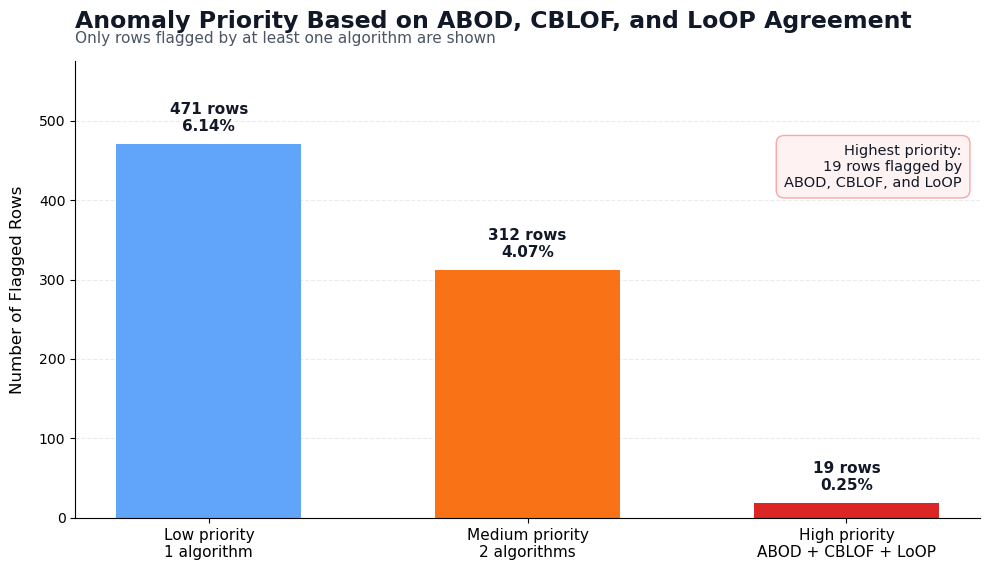

In [48]:
# ============================================================
# Cell 9C: Clean anomaly priority chart
# ============================================================

# Use the agreement table from Cell 9
priority_chart_data = algorithm_agreement_counts.copy()

# Remove the normal group from the chart
# We keep only rows that were flagged by at least one algorithm.
priority_chart_data = priority_chart_data[
    priority_chart_data["category"] != "Normal by ABOD, CBLOF, and LoOP"
].copy()

# Rename categories for cleaner chart labels
priority_chart_data["priority_level"] = priority_chart_data["category"].replace({
    "Flagged by 1 algorithm": "Low priority\n1 algorithm",
    "Flagged by 2 algorithms": "Medium priority\n2 algorithms",
    "Flagged by ABOD, CBLOF, and LoOP": "High priority\nABOD + CBLOF + LoOP"
})

# Keep logical order
priority_order = [
    "Low priority\n1 algorithm",
    "Medium priority\n2 algorithms",
    "High priority\nABOD + CBLOF + LoOP"
]

priority_chart_data["priority_level"] = pd.Categorical(
    priority_chart_data["priority_level"],
    categories=priority_order,
    ordered=True
)

priority_chart_data = priority_chart_data.sort_values("priority_level")

print("Anomaly priority summary:")
display(priority_chart_data[["priority_level", "row_count", "percentage"]])

# ------------------------------------------------------------
# Create clean professional chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.8))

colors = ["#60A5FA", "#F97316", "#DC2626"]

bars = ax.bar(
    priority_chart_data["priority_level"],
    priority_chart_data["row_count"],
    color=colors,
    width=0.58
)

# Add value labels
for bar, count, pct in zip(
    bars,
    priority_chart_data["row_count"],
    priority_chart_data["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 12,
        f"{int(count):,} rows\n{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#111827"
    )

# Title
ax.set_title(
    "Anomaly Priority Based on ABOD, CBLOF, and LoOP Agreement",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#111827"
)

# Subtitle
ax.text(
    0,
    1.04,
    "Only rows flagged by at least one algorithm are shown",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_ylabel("Number of Flagged Rows", fontsize=12, labelpad=10)
ax.set_xlabel("")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

# Add space above labels
ax.set_ylim(0, priority_chart_data["row_count"].max() * 1.22)

# Add insight box
ax.text(
    0.98,
    0.82,
    "Highest priority:\n19 rows flagged by\nABOD, CBLOF, and LoOP",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    color="#111827",
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="#FEF2F2",
        edgecolor="#FCA5A5"
    )
)

plt.tight_layout()
plt.show()

### Conclusion — Anomaly Priority Chart

This chart focuses only on rows that were flagged by at least one of the three algorithms:

- ABOD
- CBLOF
- LoOP

The normal rows were removed from the chart so that the anomaly priority levels are easier to compare.

The results show:

- **471 rows** were flagged by only 1 algorithm
- **312 rows** were flagged by 2 algorithms
- **19 rows** were flagged by ABOD, CBLOF, and LoOP together

The 19 rows flagged by all three algorithms are the strongest anomaly candidates.

These rows should be inspected first because they were detected as unusual from three different perspectives:

- angle-based unusualness from ABOD
- cluster-based unusualness from CBLOF
- local-neighborhood unusualness from LoOP

Agreement summary across ABOD, CBLOF, and LoOP:


,category,row_count,percentage,priority
0,"Normal by ABOD, CBLOF, and LoOP",6870,89.55,Normal
1,Flagged by 1 algorithm,471,6.14,Low priority
2,Flagged by 2 algorithms,312,4.07,Medium priority
3,"Flagged by ABOD, CBLOF, and LoOP",19,0.25,High priority


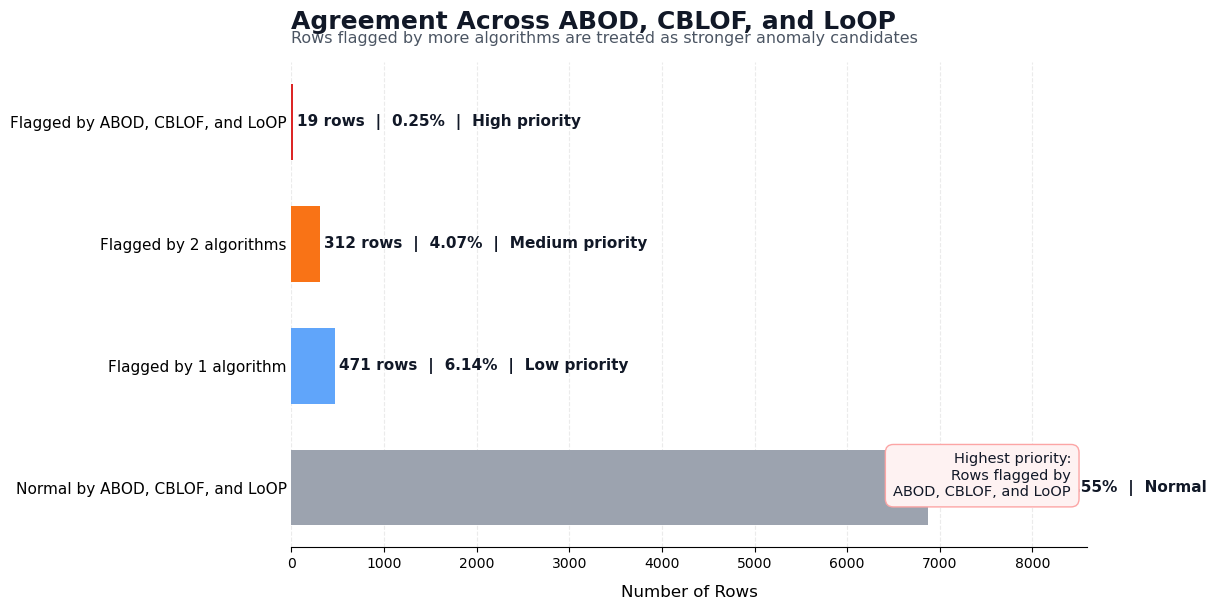

Highest-priority rows flagged by ABOD, CBLOF, and LoOP:


,temperature,pressure,vibration,humidity,equipment,location,faulty,abod_outlier,cblof_outlier,loop_outlier,algorithm_vote_count,algorithm_agreement_category
133,13.709623,6.049904,4.008917,88.839658,Pump,San Francisco,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
407,140.377511,8.230459,4.933156,13.165503,Turbine,Houston,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
725,13.135595,16.698433,4.945522,29.788237,Compressor,New York,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
830,143.513467,24.111431,0.006115,88.272602,Turbine,Atlanta,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
1133,14.612445,12.437942,0.192578,87.919799,Turbine,Atlanta,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
1921,17.066318,74.696824,2.575351,87.663777,Pump,Houston,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
1938,12.757972,46.959291,0.027240,85.985736,Pump,San Francisco,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
3050,90.095814,66.861235,0.918064,10.895922,Pump,New York,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
3489,59.066669,70.047932,3.582906,89.244911,Turbine,Chicago,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"
4317,142.144703,13.179490,0.037701,77.488446,Compressor,Chicago,1.0,True,True,True,3,"Flagged by ABOD, CBLOF, and LoOP"


In [44]:
# ============================================================
# Cell 9: Agreement table and chart across ABOD, CBLOF, and LoOP
# ============================================================

# ------------------------------------------------------------
# 1. Count how many algorithms flagged each row
# ------------------------------------------------------------

# ABOD  = angle-based outlier detection
# CBLOF = cluster-based local outlier factor
# LoOP  = local outlier probability

df_extended["algorithm_vote_count"] = (
    df_extended[["abod_outlier", "cblof_outlier", "loop_outlier"]]
    .sum(axis=1)
)

# ------------------------------------------------------------
# 2. Create readable category labels
# ------------------------------------------------------------

def assign_algorithm_agreement_category(vote_count):
    if vote_count == 0:
        return "Normal by ABOD, CBLOF, and LoOP"
    elif vote_count == 1:
        return "Flagged by 1 algorithm"
    elif vote_count == 2:
        return "Flagged by 2 algorithms"
    else:
        return "Flagged by ABOD, CBLOF, and LoOP"


df_extended["algorithm_agreement_category"] = (
    df_extended["algorithm_vote_count"]
    .apply(assign_algorithm_agreement_category)
)

# ------------------------------------------------------------
# 3. Create summary table
# ------------------------------------------------------------

category_order = [
    "Normal by ABOD, CBLOF, and LoOP",
    "Flagged by 1 algorithm",
    "Flagged by 2 algorithms",
    "Flagged by ABOD, CBLOF, and LoOP"
]

algorithm_agreement_counts = (
    df_extended["algorithm_agreement_category"]
    .value_counts()
    .reindex(category_order)
    .reset_index()
)

algorithm_agreement_counts.columns = ["category", "row_count"]

algorithm_agreement_counts["percentage"] = (
    algorithm_agreement_counts["row_count"] / len(df_extended) * 100
).round(2)

# Add a priority label for easier business interpretation
priority_map = {
    "Normal by ABOD, CBLOF, and LoOP": "Normal",
    "Flagged by 1 algorithm": "Low priority",
    "Flagged by 2 algorithms": "Medium priority",
    "Flagged by ABOD, CBLOF, and LoOP": "High priority"
}

algorithm_agreement_counts["priority"] = (
    algorithm_agreement_counts["category"]
    .map(priority_map)
)

print("Agreement summary across ABOD, CBLOF, and LoOP:")
display(algorithm_agreement_counts)

# ------------------------------------------------------------
# 4. Create professional horizontal bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6.2))

colors = ["#9CA3AF", "#60A5FA", "#F97316", "#DC2626"]

bars = ax.barh(
    algorithm_agreement_counts["category"],
    algorithm_agreement_counts["row_count"],
    color=colors,
    height=0.62
)

# Add value labels
for bar, count, pct, priority in zip(
    bars,
    algorithm_agreement_counts["row_count"],
    algorithm_agreement_counts["percentage"],
    algorithm_agreement_counts["priority"]
):
    ax.text(
        bar.get_width() + 40,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,} rows  |  {pct:.2f}%  |  {priority}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#111827"
    )

# Title
ax.set_title(
    "Agreement Across ABOD, CBLOF, and LoOP",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#111827"
)

# Subtitle
ax.text(
    0,
    1.04,
    "Rows flagged by more algorithms are treated as stronger anomaly candidates",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel("Number of Rows", fontsize=12, labelpad=10)
ax.set_ylabel("")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.tick_params(axis="y", length=0, labelsize=11)
ax.set_axisbelow(True)

# Add space for labels
ax.set_xlim(0, algorithm_agreement_counts["row_count"].max() * 1.25)

# Add explanation box
ax.text(
    0.98,
    0.10,
    "Highest priority:\nRows flagged by\nABOD, CBLOF, and LoOP",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.5,
    color="#111827",
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="#FEF2F2",
        edgecolor="#FCA5A5"
    )
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Show highest-priority anomaly candidates
# ------------------------------------------------------------

print("Highest-priority rows flagged by ABOD, CBLOF, and LoOP:")

display(
    df_extended.loc[
        df_extended["algorithm_vote_count"] == 3,
        sensor_columns + [
            "equipment",
            "location",
            "faulty",
            "abod_outlier",
            "cblof_outlier",
            "loop_outlier",
            "algorithm_vote_count",
            "algorithm_agreement_category"
        ]
    ].head(10)
)

### Conclusion — Agreement Across ABOD, CBLOF, and LoOP

The agreement analysis counted how many of the three outlier detection algorithms flagged each row.

The three algorithms were:

- **ABOD** — angle-based outlier detection
- **CBLOF** — cluster-based local outlier factor
- **LoOP** — local outlier probability

The results were:

| Category | Rows | Percentage |
|---|---:|---:|
| Normal by ABOD, CBLOF, and LoOP | 6,870 | 89.55% |
| Flagged by 1 algorithm | 471 | 6.14% |
| Flagged by 2 algorithms | 312 | 4.07% |
| Flagged by ABOD, CBLOF, and LoOP | 19 | 0.25% |

Most rows were considered normal by all three algorithms.

The most important group is:

**Flagged by ABOD, CBLOF, and LoOP**

Only **19 rows** were flagged by all three algorithms.

These rows are high-priority anomaly candidates because they were marked as unusual from three different perspectives:

- angle-based unusualness from ABOD
- cluster-based unusualness from CBLOF
- local-neighborhood unusualness from LoOP

From a machine monitoring perspective, these 19 rows should be inspected first because all three outlier detection algorithms agreed that they are suspicious.

## Step 10 — PCA View of Agreement Across ABOD, CBLOF, and LoOP

Now we visualize the agreement result in PCA space.

Instead of looking at each algorithm separately, we color each row based on how many algorithms flagged it:

- normal by ABOD, CBLOF, and LoOP
- flagged by 1 algorithm
- flagged by 2 algorithms
- flagged by ABOD, CBLOF, and LoOP

This helps us see whether the strongest anomaly candidates appear near the edges of the data cloud or inside local unusual regions.

Rows flagged by all three algorithms are the highest-priority anomaly candidates.

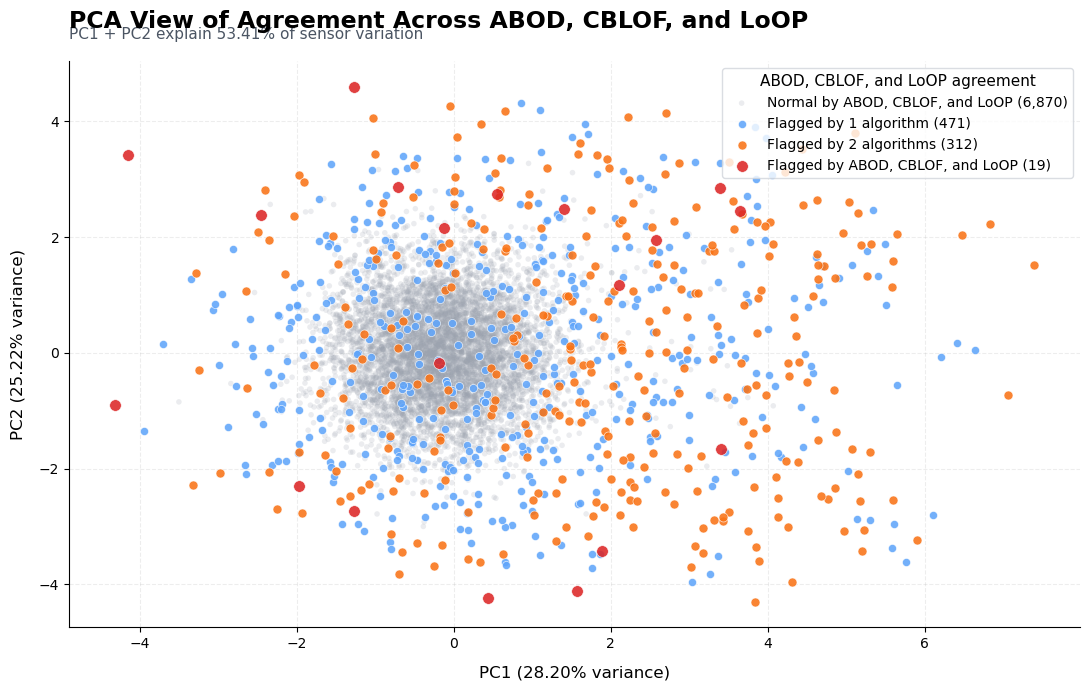

In [46]:
# ============================================================
# Cell 10: PCA scatter plot - agreement across ABOD, CBLOF, and LoOP
# ============================================================

from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Create PCA components if needed
# ------------------------------------------------------------

if "PC1" not in df_extended.columns or "PC2" not in df_extended.columns:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_components = pca.fit_transform(X_scaled)

    df_extended["PC1"] = pca_components[:, 0]
    df_extended["PC2"] = pca_components[:, 1]

    explained_variance = pca.explained_variance_ratio_
    total_explained_variance = explained_variance.sum()
else:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca.fit(X_scaled)

    explained_variance = pca.explained_variance_ratio_
    total_explained_variance = explained_variance.sum()

# ------------------------------------------------------------
# 2. Create plotting order, colors, and sizes
# ------------------------------------------------------------

plot_order = [
    "Normal by ABOD, CBLOF, and LoOP",
    "Flagged by 1 algorithm",
    "Flagged by 2 algorithms",
    "Flagged by ABOD, CBLOF, and LoOP"
]

agreement_colors = {
    "Normal by ABOD, CBLOF, and LoOP": "#9CA3AF",
    "Flagged by 1 algorithm": "#60A5FA",
    "Flagged by 2 algorithms": "#F97316",
    "Flagged by ABOD, CBLOF, and LoOP": "#DC2626"
}

agreement_sizes = {
    "Normal by ABOD, CBLOF, and LoOP": 16,
    "Flagged by 1 algorithm": 34,
    "Flagged by 2 algorithms": 42,
    "Flagged by ABOD, CBLOF, and LoOP": 70
}

# ------------------------------------------------------------
# 3. Create professional PCA scatter plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

for category in plot_order:
    subset = df_extended[df_extended["algorithm_agreement_category"] == category]
    
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=agreement_sizes[category],
        alpha=0.20 if category == "Normal by ABOD, CBLOF, and LoOP" else 0.88,
        color=agreement_colors[category],
        label=f"{category} ({len(subset):,})",
        edgecolor="white" if category != "Normal by ABOD, CBLOF, and LoOP" else "none",
        linewidth=0.45
    )

# Title
ax.set_title(
    "PCA View of Agreement Across ABOD, CBLOF, and LoOP",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

# Subtitle
ax.text(
    0,
    1.04,
    f"PC1 + PC2 explain {total_explained_variance:.2%} of sensor variation",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel(
    f"PC1 ({explained_variance[0]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    f"PC2 ({explained_variance[1]:.2%} variance)",
    fontsize=12,
    labelpad=10
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="both", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)

# Legend
ax.legend(
    title="ABOD, CBLOF, and LoOP agreement",
    frameon=True,
    facecolor="white",
    edgecolor="#D1D5DB",
    fontsize=10,
    title_fontsize=11,
    loc="best"
)

plt.tight_layout()
plt.show()

## Step 11 — Master Comparison of All Outlier Detection Algorithms

Now we compare all outlier detection algorithms used in this project section:

- Z-Score
- Isolation Forest
- LOF
- ABOD
- CBLOF
- LoOP

We compare them using:

- outlier count
- outlier percentage
- precision
- recall
- F1-score

The `faulty` column is used only for evaluation.  
The algorithms were not trained using the `faulty` label.

In [51]:
# ============================================================
# Cell 11A: Create master dataframe and recreate missing flags
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score

# Create a master dataframe using results already created in this notebook
df_master = df_extended.copy()

# ------------------------------------------------------------
# Recreate Z-Score outlier flag
# ------------------------------------------------------------

z_scores_master = (X - X.mean()) / X.std()

df_master["zscore_outlier"] = (
    z_scores_master.abs() > 3
).any(axis=1)

# ------------------------------------------------------------
# Recreate Isolation Forest outlier flag
# ------------------------------------------------------------

isolation_forest_model = IsolationForest(
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE
)

isolation_forest_labels = isolation_forest_model.fit_predict(X_scaled)

df_master["isolation_forest_outlier"] = (
    isolation_forest_labels == -1
)

# ------------------------------------------------------------
# Recreate LOF outlier flag
# ------------------------------------------------------------

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION
)

lof_labels = lof_model.fit_predict(X_scaled)

df_master["lof_outlier"] = (
    lof_labels == -1
)

print("Master dataframe prepared successfully.")
print(f"Shape: {df_master.shape}")

display(
    df_master[
        [
            "zscore_outlier",
            "isolation_forest_outlier",
            "lof_outlier",
            "abod_outlier",
            "cblof_outlier",
            "loop_outlier",
            "faulty"
        ]
    ].head()
)

Master dataframe prepared successfully.
Shape: (7672, 20)


,zscore_outlier,isolation_forest_outlier,lof_outlier,abod_outlier,cblof_outlier,loop_outlier,faulty
0,False,False,False,False,False,False,0.0
1,False,False,False,False,False,False,0.0
2,False,False,False,False,False,False,0.0
3,False,False,False,False,False,False,0.0
4,False,False,False,False,False,False,0.0


In [52]:
# ============================================================
# Cell 11B: Build master comparison metrics table
# ============================================================

# Map each algorithm name to its outlier flag column
algorithm_columns = {
    "Z-Score": "zscore_outlier",
    "Isolation Forest": "isolation_forest_outlier",
    "LOF": "lof_outlier",
    "ABOD": "abod_outlier",
    "CBLOF": "cblof_outlier",
    "LoOP": "loop_outlier"
}

# Simple explanation for each algorithm
algorithm_explanations = {
    "Z-Score": "Statistical threshold",
    "Isolation Forest": "Tree-based isolation",
    "LOF": "Local-neighborhood density",
    "ABOD": "Angle-based geometry",
    "CBLOF": "Cluster-based distance",
    "LoOP": "Local probability score"
}

# True label for evaluation
# faulty = 1 means actual faulty row
# faulty = 0 means normal row
y_true = df_master["faulty"].astype(int)

# Store results here
master_results = []

for algorithm_name, column_name in algorithm_columns.items():
    y_pred = df_master[column_name].astype(int)

    outlier_count = y_pred.sum()
    outlier_percentage = outlier_count / len(df_master) * 100

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    master_results.append({
        "algorithm": algorithm_name,
        "simple_logic": algorithm_explanations[algorithm_name],
        "outlier_count": outlier_count,
        "outlier_percentage": round(outlier_percentage, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4)
    })

# Create final comparison table
master_comparison = pd.DataFrame(master_results)

# Sort by F1-score
master_comparison_sorted = master_comparison.sort_values(
    by=["f1_score", "recall", "precision"],
    ascending=False
).reset_index(drop=True)

print("Master comparison of all outlier detection algorithms:")
display(master_comparison_sorted)

Master comparison of all outlier detection algorithms:


,algorithm,simple_logic,outlier_count,outlier_percentage,precision,recall,f1_score
0,Z-Score,Statistical threshold,467,6.09,0.9914,0.6037,0.7504
1,Isolation Forest,Tree-based isolation,384,5.01,1.0000,0.5007,0.6672
2,CBLOF,Cluster-based distance,384,5.01,1.0000,0.5007,0.6672
3,ABOD,Angle-based geometry,384,5.01,0.9453,0.4733,0.6308
4,LOF,Local-neighborhood density,384,5.01,0.6432,0.3220,0.4292
5,LoOP,Local probability score,384,5.01,0.4766,0.2386,0.3180


Ultimate hero based on F1-score:
Algorithm: Z-Score
Logic: Statistical threshold
Precision: 0.9914
Recall: 0.6037
F1-score: 0.7504


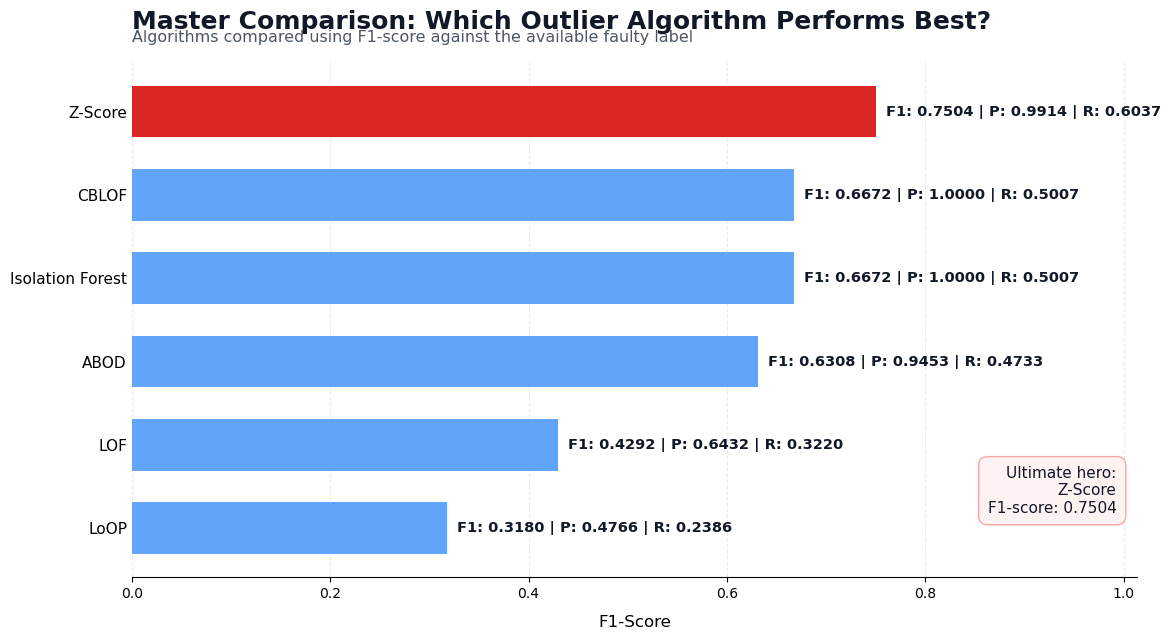

In [53]:
# ============================================================
# Cell 11C: Master comparison hero chart
# ============================================================

# Select best algorithm based on F1-score
hero = master_comparison_sorted.iloc[0]

print("Ultimate hero based on F1-score:")
print(f"Algorithm: {hero['algorithm']}")
print(f"Logic: {hero['simple_logic']}")
print(f"Precision: {hero['precision']}")
print(f"Recall: {hero['recall']}")
print(f"F1-score: {hero['f1_score']}")

# ------------------------------------------------------------
# Prepare chart data
# ------------------------------------------------------------

chart_data = master_comparison_sorted.sort_values(
    by="f1_score",
    ascending=True
)

# Highlight the best algorithm
colors = [
    "#DC2626" if algorithm == hero["algorithm"] else "#60A5FA"
    for algorithm in chart_data["algorithm"]
]

# ------------------------------------------------------------
# Create professional horizontal bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6.5))

bars = ax.barh(
    chart_data["algorithm"],
    chart_data["f1_score"],
    color=colors,
    height=0.62
)

# Add labels
for bar, f1, precision, recall in zip(
    bars,
    chart_data["f1_score"],
    chart_data["precision"],
    chart_data["recall"]
):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"F1: {f1:.4f} | P: {precision:.4f} | R: {recall:.4f}",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color="#111827"
    )

# Title
ax.set_title(
    "Master Comparison: Which Outlier Algorithm Performs Best?",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#111827"
)

# Subtitle
ax.text(
    0,
    1.04,
    "Algorithms compared using F1-score against the available faulty label",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel("F1-Score", fontsize=12, labelpad=10)
ax.set_ylabel("")

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.tick_params(axis="y", length=0, labelsize=11)
ax.set_axisbelow(True)

# Make room for text labels
ax.set_xlim(0, max(chart_data["f1_score"].max() * 1.35, 0.10))

# Hero insight box
ax.text(
    0.98,
    0.12,
    f"Ultimate hero:\n{hero['algorithm']}\nF1-score: {hero['f1_score']:.4f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    color="#111827",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#FEF2F2",
        edgecolor="#FCA5A5"
    )
)

plt.tight_layout()
plt.show()

### Conclusion — Master Comparison of Outlier Detection Algorithms

The master comparison evaluated all outlier detection algorithms using the available `faulty` label.

The algorithms compared were:

- Z-Score
- Isolation Forest
- LOF
- ABOD
- CBLOF
- LoOP

The best-performing algorithm was **Z-Score**.

Z-Score achieved:

- Precision: **0.9914**
- Recall: **0.6037**
- F1-score: **0.7504**

This means Z-Score had the best overall balance between correctly identifying faulty rows and avoiding false alarms.

Although CBLOF and Isolation Forest had perfect precision, their recall was lower than Z-Score.

This means:

- when CBLOF and Isolation Forest flagged a row, they were correct
- but they missed more actual faulty rows compared with Z-Score

LoOP had the weakest performance in this comparison.

The final result shows that for this Industrial Equipment Monitoring dataset, the simple Z-Score method performed better than the more advanced outlier detection algorithms.

This does not mean Z-Score is always the best method.  
It means Z-Score worked best for this specific dataset and available `faulty` label.